In [15]:
from pinnsform import *
from pinnsform.model import PINN, FLS, FLW, FullWavelet
import matplotlib.pyplot as plt

def load_csv_to_numpy(file_path):
    df = pd.read_csv(file_path, header=None, index_col=None, sep=",")
    return np.array(df.values)

def visualize_solution(model, mesh, mesh_shape, domain):
    prediction = f(model, mesh)[:,0].detach().cpu().numpy()
    predicted_mesh = np.reshape(prediction, mesh_shape)
    #[0,np.pi*2,1,0]
    plt.figure(figsize=(8,6))
    domain_extend = [domain[1][0], domain[1][1], domain[0][0], domain[0][1]]
    plt.imshow(predicted_mesh, extent=domain_extend, aspect='auto')
    plt.xlabel('t')
    plt.ylabel('x')
    plt.title('Predicted u(x,t)')
    plt.colorbar()
    plt.tight_layout()
    #plt.savefig('./1dreaction_pinnsformer_pred.png')
    plt.show()
    return predicted_mesh

def visualize_epoch_heatmap(data):
    #[0,np.pi*2,1,0]
    plt.figure(figsize=(8,6))
    plt.imshow(data, aspect='auto')
    plt.xlabel('t')
    plt.ylabel('x')
    plt.title('Predicted u(x,t)')
    plt.colorbar()
    plt.tight_layout()
    #plt.savefig('./1dreaction_pinnsformer_pred.png')
    plt.show()

In [2]:
device = 'cuda'

NUM_SEEDS = 100
INIT_SEEDS = np.array(range(NUM_SEEDS))

problem_domain = ([0, 2*np.pi], [0, 1])
train_points = (51, 51)

# 51x51 mesh as list
np_mesh = generate_mesh(train_points, problem_domain)
# 51x51 mesh as list with temporal sequence for every point
sequence_mesh = make_temporal_sequence(np_mesh, num_step=5, step=1e-3)
# flatten the temporal sequence for normal models
np_mesh_sequence = listify_sequence(sequence_mesh)
# make Mesh object of torch tensors
mesh = torchify(np_mesh_sequence, device, False)

In [3]:
sequence_mesh, _ = generate_mesh_object(train_points, domain=problem_domain, device=device, full_requires_grad=True, border_requires_grad=False, num_seq_steps=5, seq_step_size=1e-3)

# 51 x 51 mesh
np_mesh = generate_mesh(train_points, problem_domain)
# create spatial sequences
np_mesh_sequence = listify_sequence(make_temporal_sequence(np_mesh, 5, 1e-3))
# flatten the sequence
np_sequence_mesh = np.expand_dims(np_mesh_sequence, 1)
# make torch Mesh object
single_mesh = torchify(np_sequence_mesh, device, True)

In [16]:
temporal_locations = list(np_mesh_sequence[np_mesh_sequence[:,0] == 0][:,1])

In [26]:
def visualize_epoch_heatmap(data):
    #[0,np.pi*2,1,0]
    plt.figure(figsize=(8,6))
    plt.imshow(data, aspect='auto', cmap='hot_r', vmax=1)
    plt.xlabel('t')
    plt.ylabel('epochs')
    plt.title('Correlation')
    plt.colorbar()
    plt.tight_layout()
    #plt.savefig('./1dreaction_pinnsformer_pred.png')
    plt.show()

In [27]:
base_dir = os.getcwd()
NUM_SEEDS = 100
INIT_SEEDS = np.array(range(NUM_SEEDS))
experiment_name = "FourModels_TS_LBFGS_200"
path = os.path.join(base_dir, 'results', experiment_name, 'run')
analysis_path = os.path.join(base_dir, 'analysis', experiment_name)
model_names = ["PINN", "FLS", "FLW", "FullWavelet"]
print(analysis_path)

/local/upb/users/p/pauldf/profiles/unix/cs/pinnsformer/experiments/1d_reaction/feed_forward/analysis/FourModels_TS_LBFGS_200


PINN
[[1.         0.99999467 0.99999353 ... 0.97410748 0.97408541 0.97405668]
 [1.         0.99998755 0.99998982 ... 0.98041636 0.98038839 0.98034234]
 [1.         0.99999467 0.99999403 ... 0.97653267 0.97649482 0.97644169]
 ...
 [1.         0.999998   0.99999641 ... 0.710559   0.71022475 0.70986442]
 [1.         0.999998   0.99999641 ... 0.710559   0.71022475 0.70986442]
 [1.         0.999998   0.99999641 ... 0.710559   0.71022475 0.70986442]]


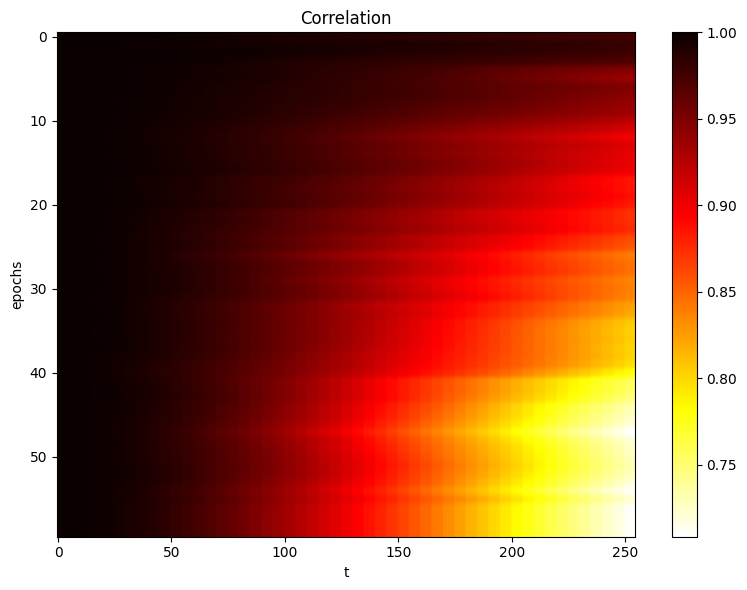

Exception: 

In [28]:
for m_name in model_names:
    print(m_name)
    model_anaylsis_path = os.path.join(analysis_path, m_name, "temporal_correlation")
    for i in INIT_SEEDS:
        corr_data_path = os.path.join(model_anaylsis_path, f"correlation_history_seed_{i}.csv")
        correlation_data = load_csv_to_numpy(corr_data_path)[1:]
        #print(correlation_data)
        visualize_epoch_heatmap(correlation_data)
        raise Exception()
    

In [61]:

def add_noise(model, noise_seed = 0, noise=0.001):
    set_random_seed(noise_seed)
    with torch.no_grad():
        for param in model.parameters():
            param.add_(torch.randn(param.size(), device=device) * noise)

def estimate_temporal_correlation(model, model_weights, mesh, repeats = 1000, noise = 0.001):
    model.load_state_dict(model_weights)
    u_before = f(model, mesh).detach().cpu().numpy()

    u_neighborhood = []
    for i in range(repeats):
        model.load_state_dict(model_weights)
        add_noise(model, noise_seed = i, noise=noise)
        u_neighborhood.append(f(model, mesh).detach().cpu().numpy())

    diffs = []
    for u_after in u_neighborhood:
        diffs.append(u_after - u_before)

    diffs = np.reshape(np.array(diffs), (repeats, 51, 51*5))
    corr_matrices = [np.corrcoef(diffs[i].T) for i in range(repeats)]
    return np.mean(corr_matrices, axis=0)[0]

def correlation_train_history(weight_history_path, estimateTC_fn):
    history = []
    for epoch in range(201):
        model_weight_path = os.path.join(weight_history_path, f"model_at_{epoch}.pth")
        if os.path.exists(model_weight_path):
            print(epoch)
            history.append(estimateTC_fn(model_weights = torch.load(model_weight_path)))
    return history

In [62]:
models = [PINN, FLS, FLW, FullWavelet]
model_names = ["PINN", "FLS", "FLW", "FullWavelet"]

for k, model_class in enumerate(models):
    model_name = model_names[k]
    print(model_name)
    model_result_path = os.path.join(path, model_name)
    model_analysis_path = os.path.join(analysis_path, model_name, "temporal_correlation")
    os.makedirs(model_analysis_path, exist_ok=True)

    rmae_list = []
    for seed in INIT_SEEDS:
        seed_folder_path = os.path.join(model_result_path, f"seed_{seed}")
        #rmae_path = os.path.join(seed_folder_path, "error.csv")
        #data = load_csv_to_numpy(rmae_path)
        #rmae_list.append(float(data[1,0]))

        # correlation history
        model = model_class(in_dim=2, hidden_dim=512, out_dim=1, num_layer=4).to(device)
        estimateTC_function = partial(estimate_temporal_correlation, model=model, mesh=mesh, repeats = 1000, noise = 0.0001)
        correlation_history = correlation_train_history(seed_folder_path, estimateTC_function)

        pd.DataFrame(np.array(correlation_history), columns=temporal_locations).to_csv(os.path.join(model_analysis_path, f"correlation_history_seed_{seed}.csv"), index = False)
        raise Exception()
    #print(sum(np.array(rmae_list) > 0.5))

PINN
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
200


Exception: 

In [6]:
np.array(rmae_list)

array([0.97801155, 0.04571613, 0.98249644, 0.03602007, 0.06991246,
       0.98026973, 0.04960532, 0.0408562 , 0.9760824 , 0.0619488 ,
       0.08446141, 0.9783058 , 0.06014762, 0.9807654 , 0.04513766,
       0.04670413, 0.03398494, 0.05335687, 0.97963715, 0.97833246,
       0.0548591 , 0.0430732 , 0.06768874, 0.9797786 , 0.05068836,
       0.04657618, 0.06588363, 0.06106064, 0.06249919, 0.983434  ,
       0.05451934, 0.03237362, 0.04919808, 0.05339787, 0.9739338 ,
       0.06552296, 0.0599217 , 0.04986058, 0.98081475, 0.06419068,
       0.0593783 , 0.08291984, 0.07072879, 0.0413413 , 0.97842604,
       0.02583273, 0.9817543 , 0.9772853 , 0.9810377 , 0.04814389,
       0.04788169, 0.9814535 , 0.04392827, 0.0473782 , 0.06358519,
       0.05950176, 0.06203129, 0.07168394, 0.04370541, 0.9784825 ,
       0.07492605, 0.06517199, 0.97995275, 0.05420304, 0.05977938,
       0.05305286, 0.062899  , 0.97969097, 0.9779716 , 0.06103129,
       0.05285799, 0.97771937, 0.9791704 , 0.9777232 , 0.97803

In [7]:
mean_init_values = []
mean_abs_dfx = []
mean_abs_dft = []
for i in INIT_SEEDS:
    weight_path = os.path.join(init_path, "PINN_shifted", f"seed_{i}", "init_model.pth")
    model = PINN_shifted(in_dim=2, hidden_dim=512, out_dim=1, num_layer=4).to(device)
    model.load_state_dict(torch.load(weight_path))
    pred = f(model, mesh).detach().cpu().numpy()
    dfx = df(model, mesh, wrt=0).detach().cpu().numpy()
    dft = df(model, mesh, wrt=1).detach().cpu().numpy()
    mean_abs_dfx.append(np.mean(dfx))
    mean_abs_dft.append(np.mean(dft))
    mean_init_values.append(np.mean(pred))


In [8]:
init_error_stack = np.stack([mean_init_values, mean_abs_dfx, mean_abs_dft, rmae_list], axis=1)
print("mav\tmeandfx\tmeandft\trmae")
for entry in init_error_stack[init_error_stack[:,0].argsort()]:
    print(f"{entry[0]}\t{entry[1]}\t{entry[2]}\t{entry[3]}")

mav	meandfx	meandft	rmae
-0.07606388628482819	-0.1584070920944214	0.054754067212343216	0.9760824
0.013119371607899666	-0.1625625491142273	0.1524941623210907	0.356626
0.10735797137022018	-0.07891087979078293	-0.15619860589504242	0.97969097
0.14604336023330688	-0.09577064961194992	-0.05041637271642685	0.033984937
0.1545189917087555	-0.06541429460048676	-0.14448398351669312	0.9807654
0.16701211035251617	-0.0943116843700409	-0.03852728009223938	0.9726853
0.18527266383171082	-0.07177021354436874	-0.12996160984039307	0.9823663
0.19762173295021057	-0.07209932804107666	-0.049733929336071014	0.9779716
0.20147359371185303	-0.06892365962266922	-0.07359791547060013	0.9821405
0.21997475624084473	-0.07220000773668289	-0.01891939714550972	0.97842604
0.23086296021938324	-0.08746033161878586	0.10358820855617523	0.97801155
0.2680666446685791	-0.07088170200586319	-0.031656231731176376	0.9791704
0.27958160638809204	-0.06074271723628044	-0.08800961822271347	0.9780997
0.2823667824268341	-0.07085676491260529

In [6]:
base_dir = os.getcwd()
experiment_name = "SixModels_32Bit_LBFGS_TS"
trained_path = os.path.join(base_dir, 'results', experiment_name, '51mesh', 'seed_1', 'trained_model.pth')
init_path = os.path.join(base_dir, 'results', experiment_name, 'InitWeights', 'seed_1', 'init_model.pth')
init_tanh_path = os.path.join(base_dir, 'results', experiment_name, '20240924_120425', 'seed_1', 'init_model.pth')
trained_tanh_path = os.path.join(base_dir, 'results', experiment_name, '20240924_120425', 'seed_1', 'trained_model.pth')

In [40]:
trained_model.load_state_dict(torch.load(trained_path))
init_model.load_state_dict(torch.load(init_path))
init_model_tanh.load_state_dict(torch.load(init_tanh_path))
trained_model_tanh.load_state_dict(torch.load(trained_tanh_path))

<All keys matched successfully>

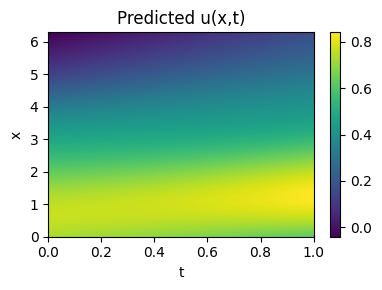

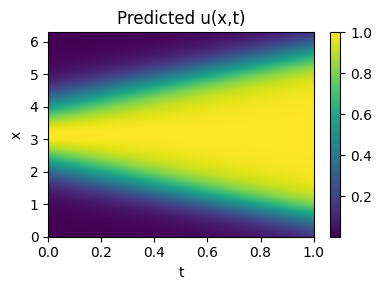

array([[0.00098121, 0.00103203, 0.00108416, ..., 0.15738767, 0.16075338,
        0.16417487],
       [0.00112174, 0.00116709, 0.00121334, ..., 0.16975538, 0.17332467,
        0.17695001],
       [0.00127633, 0.00131623, 0.00135866, ..., 0.18292876, 0.18670574,
        0.19054295],
       ...,
       [0.0018441 , 0.00186048, 0.00188168, ..., 0.17788975, 0.18155563,
        0.1852812 ],
       [0.00173618, 0.00174551, 0.0017587 , ..., 0.16724032, 0.17073208,
        0.17428078],
       [0.00162305, 0.00162685, 0.00163425, ..., 0.15739806, 0.16072454,
        0.16410385]], dtype=float32)

In [42]:
visualize_solution(init_model, test_mesh, test_points, problem_domain)
visualize_solution(trained_model, test_mesh, test_points, problem_domain)

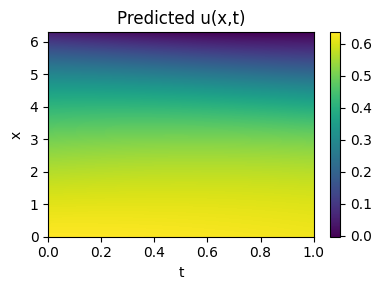

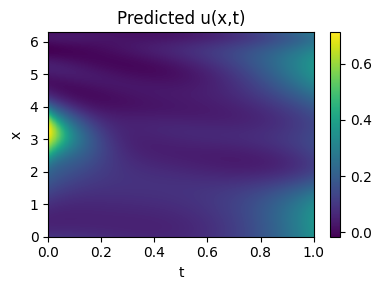

array([[0.01099288, 0.01190588, 0.01276338, ..., 0.28376117, 0.28823715,
        0.29275608],
       [0.01642197, 0.0172551 , 0.01802582, ..., 0.27250403, 0.27686703,
        0.28127062],
       [0.02034223, 0.0211077 , 0.02181393, ..., 0.26377368, 0.26803553,
        0.27233005],
       ...,
       [0.08327284, 0.08303151, 0.08280176, ..., 0.33982995, 0.34545198,
        0.3511346 ],
       [0.08758035, 0.08732167, 0.08706194, ..., 0.33893374, 0.3445215 ,
        0.3501632 ],
       [0.09219635, 0.09192342, 0.09162018, ..., 0.33808935, 0.34363103,
        0.3492392 ]], dtype=float32)

In [38]:
visualize_solution(init_model_tanh, test_mesh, test_points, problem_domain)
visualize_solution(trained_model_tanh, test_mesh, test_points, problem_domain)

In [35]:
RHO = 5.0

def h(x):
    return np.exp( - (x-np.pi)**2 / (2 * (np.pi/4)**2))

def u_ana(x,t):
    return h(x) * np.exp(RHO*t) / ( h(x) * np.exp(RHO*t) + 1 - h(x))

test_points = (201, 201)
test_mesh, _ = generate_mesh_object(test_points, domain=problem_domain, device=device, full_requires_grad=False, border_requires_grad=False, num_seq_steps=5, seq_step_size=1e-3)
print('TEST MESH')
print(test_mesh.part[0][:,0].shape)
print(test_mesh.part[1][:,0].shape)
print('#'*20)
analytic_solution = u_ana(test_mesh.part[0][:,0].cpu().numpy(), test_mesh.part[1][:,0].cpu().numpy())


TEST MESH
torch.Size([40401, 1])
torch.Size([40401, 1])
####################


In [56]:
analytic_mesh = np.reshape(analytic_solution, test_points)

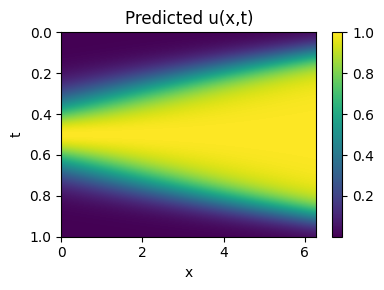

In [57]:
plt.figure(figsize=(4,3))
plt.imshow(analytic_mesh, extent=[0,np.pi*2,1,0], aspect='auto')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Predicted u(x,t)')
plt.colorbar()
plt.tight_layout()
plt.savefig('./1dreaction_pinnsformer_pred.png')
plt.show()

In [73]:
class POSPINN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, num_layer):
        super(POSPINN, self).__init__()

        layers = []
        for i in range(num_layer-1):
            if i == 0:
                layers.append(nn.Linear(in_features=in_dim, out_features=hidden_dim))
                layers.append(nn.Tanh())
            else:
                layers.append(nn.Linear(in_features=hidden_dim, out_features=hidden_dim))
                layers.append(nn.Tanh())

        layers.append(nn.Linear(in_features=hidden_dim, out_features=out_dim))

        self.linear = nn.Sequential(*layers)

    def forward(self, x):
        print(x)
        return self.linear(x)

In [74]:
device = 'cuda'

In [75]:
def init_weights(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
        m.bias.data.fill_(0.0)


In [76]:
base_model = POSPINN(in_dim=2, hidden_dim=512, out_dim=1, num_layer=4).to(device)
set_random_seed(0)
base_model.apply(init_weights)

POSPINN(
  (linear): Sequential(
    (0): Linear(in_features=2, out_features=512, bias=True)
    (1): Tanh()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): Tanh()
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): Tanh()
    (6): Linear(in_features=512, out_features=1, bias=True)
  )
)

In [77]:
pred = f(base_model, mesh).detach().cpu().numpy()
mean_init_value = np.mean(pred)
print(mean_init_value)

tensor([[0.0000e+00, 0.0000e+00],
        [0.0000e+00, 1.0000e-03],
        [0.0000e+00, 2.0000e-03],
        ...,
        [6.2832e+00, 1.0020e+00],
        [6.2832e+00, 1.0030e+00],
        [6.2832e+00, 1.0040e+00]], device='cuda:0', grad_fn=<CatBackward0>)
-0.23488143


In [70]:
dfx = df(base_model, mesh, wrt=0).detach().cpu().numpy()
dft = df(base_model, mesh, wrt=1).detach().cpu().numpy()
print(np.mean(np.abs(dfx)))
print(np.mean(np.abs(dft)))

0.08793949
0.10361822


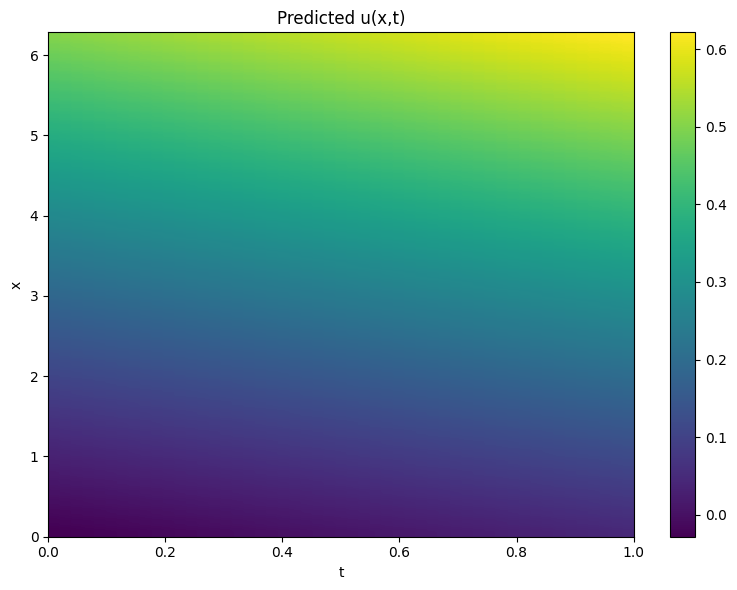

array([[ 0.5       ,  0.5001226 ,  0.5002453 , ...,  0.62164265,
         0.62176156,  0.6218806 ],
       [ 0.48735294,  0.48747557,  0.48759815, ...,  0.60911644,
         0.60923564,  0.60935485],
       [ 0.4747133 ,  0.4748358 ,  0.4749583 , ...,  0.59653187,
         0.59665126,  0.5967706 ],
       ...,
       [-0.01300931, -0.01293665, -0.01286381, ...,  0.06374973,
         0.06382978,  0.06391048],
       [-0.02079111, -0.02071953, -0.02064818, ...,  0.05465484,
         0.05473375,  0.05481273],
       [-0.02845383, -0.02838361, -0.02831328, ...,  0.04568869,
         0.04576617,  0.04584405]], dtype=float32)

In [69]:
visualize_solution(base_model, mesh, (51,51*5), problem_domain)